# Tutorial 5: PyMC Surrogate Learning (`pymc_gp`)

Estimated time: 30-50 minutes

## Prerequisites
`pymc` and `arviz` installed.

## Learning aims
- Primary package aim: fit/evaluate surrogate models through the CLI and inspect artifacts
- Secondary scientific aim: build intuition for prior, posterior, and posterior predictive uncertainty

## Success criteria
- you can train a PyMC surrogate, evaluate new inputs, and interpret uncertainty width


## Why this tutorial matters

A **surrogate** is a fast probabilistic model fit to a sweep's outputs that lets you replace the simulator at inference time — predict at any input without re-running the model. The PyMC GP surrogate gives you a *posterior predictive*: every prediction comes with a **width** (a posterior standard deviation), not just a point estimate. Reading those widths is what separates "the surrogate said 0.42" from "the surrogate said 0.42 ± 0.01, and I trust the prediction here because the training set covers this region densely."

**Callback to T1:** at the bottom of T1 you held a question — "would you trust a surrogate's prediction at `a=0.5, b=0.5`?" This is the tutorial where you answer it. After Step 4 you'll be able to look at any predictive width and decide whether to trust the prediction or run the simulator at that input instead.


## Step 1: Ensure training dataset exists


In [1]:
# Cross-platform setup (Windows / macOS / Linux) — no shell, no PYTHONPATH prefix.
# Find the repo root so `src/` is importable, then load the shared tutorial helpers.
import sys
from pathlib import Path

_root = Path.cwd().resolve()
while not (_root / "src" / "bayesian_metamodeling").is_dir() and _root != _root.parent:
    _root = _root.parent
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))

from bayesian_metamodeling.tutorial import bootstrap, run_mm_cli, run_tool

root = bootstrap()  # chdir to repo root + ensure src/ on sys.path (idempotent)
ROOT = root
print("Repo root:", root)


Repo root: /Users/barakraveh/Git/metamodeler_codex_scaffold_docs


In [2]:
run_mm_cli('run', 'tutorials/specs/model.toy.grid.json')


$ bayesmm run tutorials/specs/model.toy.grid.json
Running point 1/9: {'a': 0.0, 'b': 0.0}
Running point 2/9: {'a': 0.0, 'b': 1.0}
Running point 3/9: {'a': 0.0, 'b': 2.0}
Running point 4/9: {'a': 1.0, 'b': 0.0}
Running point 5/9: {'a': 1.0, 'b': 1.0}
Running point 6/9: {'a': 1.0, 'b': 2.0}
Running point 7/9: {'a': 2.0, 'b': 0.0}
Running point 8/9: {'a': 2.0, 'b': 1.0}
Running point 9/9: {'a': 2.0, 'b': 2.0}
Stored sweep run: cf2bdb8dbb6f488581e640fcbd23008e
Run complete: 9 successful runs


0

## Step 2: Fit surrogate and list artifacts


In [3]:
run_mm_cli('surrogate', 'fit', 'tutorials/specs/surrogate.toy.pymc_gp.json')
run_mm_cli('surrogate', 'list')


$ bayesmm surrogate fit tutorials/specs/surrogate.toy.pymc_gp.json
Surrogate artifact stored: artifact_id=ba0f87ea55c54a68b4bb296349b9bfb0 path=tmp/surrogate_artifacts/ba0f87ea55c54a68b4bb296349b9bfb0/artifact.json
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [beta, intercept, sigma]
Sampling 1 chain for 300 tune and 300 draw iterations (300 + 300 draws total) took 0 seconds.
$ bayesmm surrogate list
Surrogate artifacts: 32
- 061276af338347f1977fca0170286e27: tmp/surrogate_artifacts/061276af338347f1977fca0170286e27/artifact.json
- 0db1d39e0dbf40038ee8eb710fed6df4: tmp/surrogate_artifacts/0db1d39e0dbf40038ee8eb710fed6df4/artifact.json
- 1520ec6fc87b4e7eac7b54bed7ea12aa: tmp/surrogate_artifacts/1520ec6fc87b4e7eac7b54bed7ea12aa/artifact.json
- 1bb340491ce141eeb98859ccc1fe4d28: tmp/surrogate_artifacts/1bb340491ce141eeb98859ccc1fe4d28/artifact.json
- 1de7c11c7db24b8dac49fb68e8106a85: tmp/surrogate_artifacts/1de7c11c7db24b8dac49fb68e8106a85/artif

0

## Step 3: Evaluate on new inputs


In [4]:
run_mm_cli('surrogate', 'eval', 'tutorials/specs/surrogate.toy.pymc_gp.json', '--inputs', '{"a":[0.25,0.75,1.25,1.75],"b":[0.2,0.6,1.0,1.4]}', '--n', '200')


$ bayesmm surrogate eval tutorials/specs/surrogate.toy.pymc_gp.json --inputs {"a":[0.25,0.75,1.25,1.75],"b":[0.2,0.6,1.0,1.4]} --n 200
{
  "artifact_id": "ba0f87ea55c54a68b4bb296349b9bfb0",
  "backend": "pymc_gp",
  "n": 200,
  "sample_shape": [
    4,
    200
  ],
  "samples_preview": [
    [
      0.45000273770277566,
      0.45000249092344186,
      0.45000017988502844,
      0.4500005493226076,
      0.4499997381471338
    ],
    [
      1.3499996488325907,
      1.3499975254418024,
      1.3500027454015298,
      1.3499999791115262,
      1.3500014099461821
    ],
    [
      2.2499970843726076,
      2.249999410584821,
      2.2499998323515515,
      2.250000055045403,
      2.250001612048175
    ]
  ],
  "summary": {
    "mean": [
      0.45000003636909214,
      1.350000017172531,
      2.2499999979759697,
      3.149999978779409
    ],
    "n": 4,
    "output_correlation": "diagonal",
    "posterior_draws": 300,
    "std": [
      1.5694014373483749e-06,
      1.56468420377212

0

## Step 4: Plot predictive mean and uncertainty (graphic)


## Mini-lesson: prior, posterior, posterior predictive (read this BEFORE the plot)

Three Bayesian terms you'll see across this curriculum:

- **Prior**: your beliefs about the model parameters *before* seeing data. For a GP surrogate, the prior is over the function shape (smoothness via a kernel, output scale, noise) — not over the output `y` directly.
- **Posterior**: your updated beliefs about those parameters *after* the GP has been conditioned on the 9 training observations. Tighter than the prior wherever data was informative.
- **Posterior predictive**: the distribution over the *output* `y` at a *new* input, integrating over the posterior. This is what `eval_surrogate` returns: a `mean` (point estimate) and a `std` (posterior width). The width is the answer to "how sure is the GP about this prediction?"

When you look at the errorbar plot below, the dots are the posterior predictive *means*; the bars are the posterior predictive *standard deviations*. Wider bars = the GP is less sure. Narrower bars = it has enough nearby training data to be confident.


**Common confusion: these errorbars are NOT confidence intervals.** They're the *posterior predictive standard deviation* — the GP's belief about how uncertain it is at each query point given its training data. Specifically, they are NOT:

- a frequentist confidence interval ("95% of resampled estimates would fall here") — wrong framework entirely;
- the *simulator's* noise — there is none here; the toy is deterministic;
- a constant scaled by the data's spread — they vary across query points based on how close the query is to training data.

If you doubled the training data (a denser grid), these widths would shrink. If you queried at an input far from any training point, they'd grow. **That responsiveness to data support is the difference a Bayesian surrogate makes** vs a point-prediction model that gives you the same width everywhere.

**Heads-up about the plot below:** for this particular toy (`y = a + b` is a perfectly linear, deterministic function and 9 training points cover the box well), the GP is *very* confident — the std comes out around `1e-7`, so the errorbars are basically invisible. The augmented plot annotates the actual std numerically and overlays the analytical truth so you can see the mean is calibrated. With a noisier or sparser training set, you'd see the bars open up.


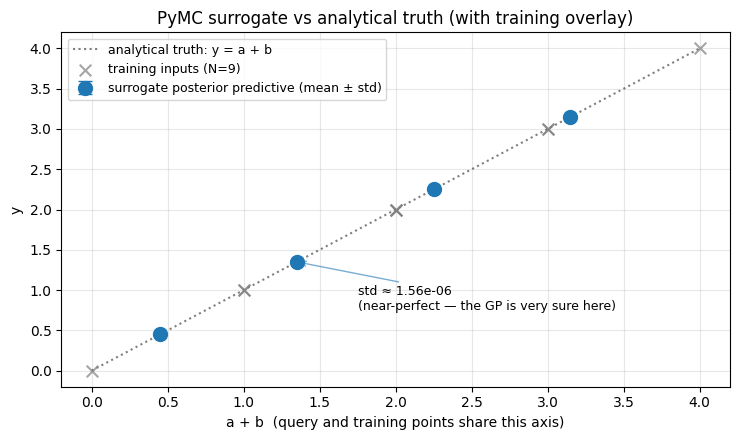


Numeric check (4 query points):
  predicted mean: [0.45, 1.35, 2.25, 3.15]
  analytical y :  [0.45, 1.35, 2.25, 3.15]
  std (each)   :  [1.57e-06, 1.56e-06, 1.56e-06, 1.57e-06]


In [5]:
import csv
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from bayesian_metamodeling.spec import SurrogateSpec
from bayesian_metamodeling.surrogates import eval_surrogate

root = Path.cwd().resolve()
if not (root / "src").is_dir() and (root.parent / "src").is_dir():
    root = root.parent

spec_payload = json.loads((root / "tutorials/specs/surrogate.toy.pymc_gp.json").read_text())
spec = SurrogateSpec.model_validate(spec_payload)

# --- Query points (4 inputs the surrogate hasn't seen) ---
inputs = {"a": [0.25, 0.75, 1.25, 1.75], "b": [0.2, 0.6, 1.0, 1.4]}
result = eval_surrogate(spec=spec, inputs_payload=inputs, n=300)
mean = np.asarray(result["summary"]["mean"], dtype=float)
std = np.asarray(result["summary"].get("std", [0.0] * len(mean)), dtype=float)

# --- Find the toy training sweep CSV (whichever sweep populated tmp/tutorials/toy_store) ---
sweep_csv = next(
    (root / "tmp/tutorials/toy_store/sweeps").glob("*/sweep_rows.csv"),
    None,
)
train_a, train_b, train_y = [], [], []
if sweep_csv is not None:
    with open(sweep_csv) as f:
        reader = csv.DictReader(f)
        for row in reader:
            if row.get("status") != "success":
                continue
            train_a.append(float(row["a"]))
            train_b.append(float(row["b"]))
            # The toy outputs `y = [a+b, a*b]`; the surrogate trained on the first column.
            train_y.append(float(row.get("y__0", float(row["a"]) + float(row["b"]))))
train_a = np.asarray(train_a)
train_b = np.asarray(train_b)
train_y = np.asarray(train_y)

# Use `a + b` as x-axis (since the underlying truth is y = a + b, this lays the predictions and
# the training points on the same calibration curve).
query_x = np.asarray(inputs["a"]) + np.asarray(inputs["b"])
query_truth = query_x  # analytical truth: y = a + b

train_x = train_a + train_b

fig, ax = plt.subplots(figsize=(7.5, 4.5))

# Analytical truth as a reference line
xx = np.linspace(0, 4, 50)
ax.plot(xx, xx, "k:", alpha=0.5, label="analytical truth: y = a + b")

# Training observations
ax.scatter(
    train_x, train_y, marker="x", s=70, c="tab:gray",
    alpha=0.7, label=f"training inputs (N={len(train_x)})", zorder=3,
)

# Surrogate predictions with errorbars
ax.errorbar(
    query_x, mean, yerr=std, fmt="o", color="tab:blue",
    markersize=10, capsize=5, label="surrogate posterior predictive (mean ± std)", zorder=4,
)

# Annotate one query point with its actual std value (since the bars are tiny)
ax.annotate(
    f"std ≈ {std[1]:.2e}\n(near-perfect — the GP is very sure here)",
    xy=(query_x[1], mean[1]),
    xytext=(query_x[1] + 0.4, mean[1] - 0.6),
    fontsize=9, ha="left",
    arrowprops=dict(arrowstyle="->", color="tab:blue", alpha=0.6),
)

ax.set_title("PyMC surrogate vs analytical truth (with training overlay)")
ax.set_xlabel("a + b  (query and training points share this axis)")
ax.set_ylabel("y")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nNumeric check (4 query points):")
print(f"  predicted mean: {[float(f'{m:.4f}') for m in mean]}")
print(f"  analytical y :  {[float(f'{t:.4f}') for t in query_truth]}")
print(f"  std (each)   :  {[float(f'{s:.2e}') for s in std]}")


## Optional appendix: confidence check that the PyMC backend works

The cell below runs a single regression test from the package's own test suite. It's not part of the lesson — it's just a "is my PyMC install actually functional" smoke test you can run if anything earlier surprised you. Skip on first read.


In [6]:
run_tool('pytest', '-q', 'tests/test_surrogate_backends.py', '-k', 'pymc_gp_backend_fit_sample_and_logprob')


$ pytest -q tests/test_surrogate_backends.py -k pymc_gp_backend_fit_sample_and_logprob


.                                                                        [100%]


0